# Binary Group Composition on $\mathbb{Z}_n^2 \rtimes C_m$

**Group:** $\mathbb{Z}_n^2 \rtimes C_m$ — translations and rotations on a discrete lattice (order $mn^2$), where $m \in \{1, 2, 3, 4, 6\}$ (crystallographic restriction).  
**Semidirect product:** The generator $g$ of $C_m$ acts on $\mathbb{Z}_n^2$ via a rotation matrix $A$, so $(x_1, y_1, r_1) \cdot (x_2, y_2, r_2) = ((x_1, y_1) + A^{r_1}(x_2, y_2) \bmod n,\; r_1 + r_2 \bmod m)$.  
**Task:** Given encodings of two group elements $g_1, g_2$, predict the encoding of their product $g_1 \cdot g_2$.  
**Sequence length:** $k = 2$ (binary composition).  
**Architecture:** `TwoLayerMLP` with square nonlinearity.

## To do with Fran:
1. Lets extend to $C_n^2 \rtimes C_m$ for $m = 1, 2, 3, 4, 6$
2. Let's discuss the irreps. Are they correct? 
3. Whats going on when we create a template vector that is not one-hot? One is a "good" template? Fix the bug in power.
4. Lets discuss the visualization of the weights. Is what I am doing now "correct"? What would be a better visualization?

## Imports

In [1]:
import os
import random

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from src.groups import ZnxZnxCmGroup
import src.dataset as dataset
import src.model as model
import src.optimizer as optimizer
import src.template as template
import src.train as train_mod
import src.viz as viz

## Specify device

In [2]:
# Set this to e.g. "cuda:0", "cuda:1", or "cpu"
device_name = "cuda:0"

if device_name.startswith("cuda") and not torch.cuda.is_available():
    print("Warning: CUDA not available, falling back to CPU")
    device = torch.device("cpu")
else:
    device = torch.device(device_name)

print(f"Using device: {device}")

Using device: cuda:0


## Configuration

In [4]:
TEST_MODE = os.environ.get("NOTEBOOK_TEST_MODE", "0") == "1"

seed = 10
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

n = 3
m = 3  # rotation order: one of {1, 2, 3, 4, 6}
group = ZnxZnxCmGroup(n=n, m=m)
group_size = group.order

ROTATION_ANGLES = {1: [0], 2: [0, 180], 3: [0, 120, 240], 4: [0, 90, 180, 270], 6: [0, 60, 120, 180, 240, 300]}
angles = ROTATION_ANGLES[m]
group_label = f"Z_{n}^2 ⋊ C_{m}"
group_label_latex = f"$\\mathbb{{Z}}_{{{n}}}^2 \\rtimes C_{{{m}}}$"
file_tag = f"znxzn_c{m}"

hidden_dim = 20 if TEST_MODE else 600
epochs = 2 if TEST_MODE else 10000
lr = 0.01
init_scale = 1e-3

FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"Group: {group_label}, order {group_size}")

Group: Z_3^2 ⋊ C_3, order 27


In [5]:
group.irreps()

[IrreducibleRepresentation(name='ZnZnCm_n3_m3|1d_orb0_s0', size=1),
 IrreducibleRepresentation(name='ZnZnCm_n3_m3|1d_orb0_s1', size=1),
 IrreducibleRepresentation(name='ZnZnCm_n3_m3|1d_orb0_s2', size=1),
 IrreducibleRepresentation(name='ZnZnCm_n3_m3|1d_orb1_s0', size=1),
 IrreducibleRepresentation(name='ZnZnCm_n3_m3|1d_orb1_s1', size=1),
 IrreducibleRepresentation(name='ZnZnCm_n3_m3|1d_orb1_s2', size=1),
 IrreducibleRepresentation(name='ZnZnCm_n3_m3|1d_orb2_s0', size=1),
 IrreducibleRepresentation(name='ZnZnCm_n3_m3|1d_orb2_s1', size=1),
 IrreducibleRepresentation(name='ZnZnCm_n3_m3|1d_orb2_s2', size=1),
 IrreducibleRepresentation(name='ZnZnCm_n3_m3|3d_orb0_s0', size=3),
 IrreducibleRepresentation(name='ZnZnCm_n3_m3|3d_orb1_s0', size=3)]

## Template and Dataset

In [13]:
#tpl = template.one_hot(group_size)
tpl = template.custom_fourier(group, [0.0, 100, 75, 50, 25, 10])

pair_ds = dataset.GroupCompositionDataset(
    group, 
    template=tpl, 
    k=2, 
    mode="exhaustive",
)

N = len(pair_ds)
X_tensor = pair_ds.X.to(device)
Y_tensor = pair_ds.Y.to(device)

ds = TensorDataset(X_tensor, Y_tensor)
dataloader = DataLoader(ds, batch_size=len(ds), shuffle=False)

print(f"Dataset: {len(ds)} samples (all {group_size}x{group_size} pairs)")
print(f"X shape: {X_tensor.shape}, Y shape: {Y_tensor.shape}")

AssertionError: powers must have 11 values (one per irrep), got 6

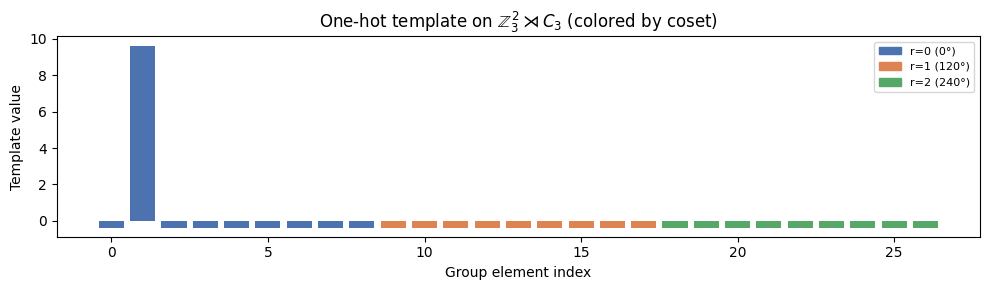

In [8]:
# Visualize template
fig, ax = plt.subplots(figsize=(10, 3))

_palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860']
colors = _palette[:m]
coset_labels = [f"r={r} ({angles[r]}°)" for r in range(m)]
bar_colors = [colors[idx // (n * n)] for idx in range(group_size)]

ax.bar(range(group_size), tpl, color=bar_colors)
ax.set_xlabel("Group element index")
ax.set_ylabel("Template value")
ax.set_title(f"One-hot template on {group_label_latex} (colored by coset)")

import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=colors[i], label=coset_labels[i]) for i in range(m)]
ax.legend(handles=patches, fontsize=8)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/{file_tag}_template.pdf", bbox_inches="tight")
plt.show()

## Cayley Table

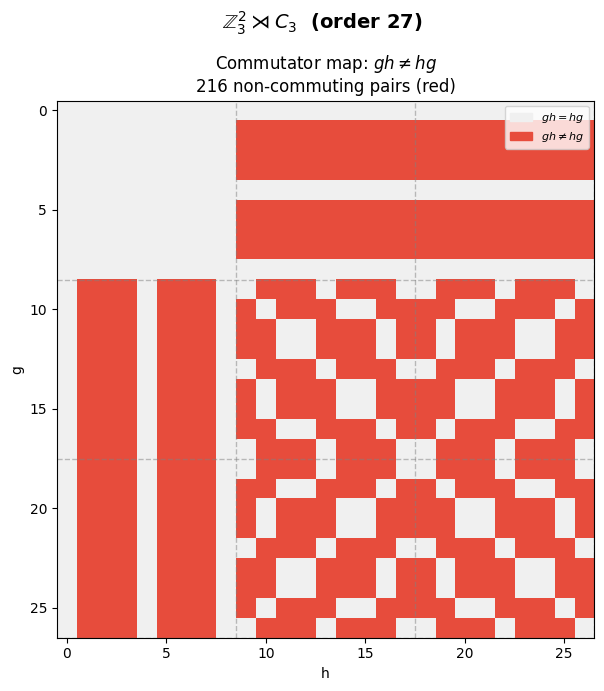

In [9]:
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

cayley = np.array([[group.compose(g, h) for h in range(group_size)] for g in range(group_size)])

fig, ax = plt.subplots(figsize=(8, 7))

commutator = (cayley != cayley.T).astype(int)
n_noncommuting = commutator.sum() // 2
cmap_comm = ListedColormap(['#f0f0f0', '#e74c3c'])
ax.imshow(commutator, cmap=cmap_comm, vmin=0, vmax=1)
for pos in np.arange(n * n - 0.5, group_size, n * n):
    ax.axhline(pos, color='gray', linewidth=1, linestyle='--', alpha=0.5)
    ax.axvline(pos, color='gray', linewidth=1, linestyle='--', alpha=0.5)
ax.set_xlabel('h')
ax.set_ylabel('g')
ax.set_title(f'Commutator map: $gh \\neq hg$\n{n_noncommuting} non-commuting pairs (red)')
patches = [mpatches.Patch(color='#f0f0f0', label='$gh = hg$'),
           mpatches.Patch(color='#e74c3c', label='$gh \\neq hg$')]
ax.legend(handles=patches, fontsize=8, loc='upper right')

plt.suptitle(f'{group_label_latex}  (order {group_size})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/{file_tag}_commutator_map.pdf", bbox_inches="tight")
plt.show()

## Model (TwoLayerMLP) and Optimizer

In [10]:
net = model.TwoLayerMLP(
    group_size=group_size,
    hidden_dim=hidden_dim,
    k=2,
    nonlinearity="square",
    init_scale=init_scale,
)
net = net.to(device)

criterion = nn.MSELoss()
opt = optimizer.PerNeuronScaledSGD(net, lr=lr)

print(f"Model: TwoLayerMLP(group_size={group_size}, hidden_dim={hidden_dim}, k=2, init_scale={init_scale})")
print(f"Optimizer: PerNeuronScaledSGD(lr={lr}, degree={opt.param_groups[0]['degree']})")
print(f"Training for {epochs} epochs")

Model: TwoLayerMLP(group_size=27, hidden_dim=600, k=2, init_scale=0.001)
Optimizer: PerNeuronScaledSGD(lr=0.01, degree=2)
Training for 10000 epochs


## Training

In [11]:
loss_history, val_loss_history, param_history, param_save_epochs, final_epoch = train_mod.train(
    net,
    dataloader,
    criterion,
    opt,
    epochs=epochs,
    verbose_interval=max(1, epochs // 10),
    grad_clip=0.1,
    save_param_interval=1,
)

[Epoch  1000 (seg  1000/10000)] loss: 3.566525 | reduction:    0.0%
[Epoch  2000 (seg  2000/10000)] loss: 3.333180 | reduction:    6.5%
[Epoch  3000 (seg  3000/10000)] loss: 2.538702 | reduction:   28.8%
[Epoch  4000 (seg  4000/10000)] loss: 1.882626 | reduction:   47.2%
[Epoch  5000 (seg  5000/10000)] loss: 0.910404 | reduction:   74.5%
[Epoch  6000 (seg  6000/10000)] loss: 0.253323 | reduction:   92.9%
[Epoch  7000 (seg  7000/10000)] loss: 0.026091 | reduction:   99.3%
[Epoch  8000 (seg  8000/10000)] loss: 0.004958 | reduction:   99.9%
[Epoch  9000 (seg  9000/10000)] loss: 0.001746 | reduction:  100.0%
[Epoch 10000 (seg 10000/10000)] loss: 0.000856 | reduction:  100.0%


## Training Loss

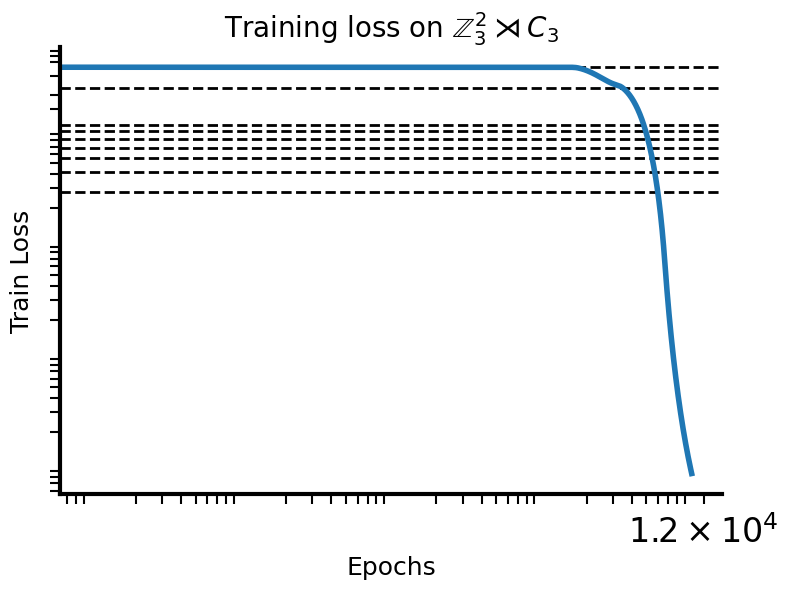

In [12]:
theory_levels = viz.loss_plateau_predictions(tpl, group)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(loss_history, lw=4)

for level in theory_levels[:-1]:
    ax.axhline(y=level, color="black", linestyle="--", linewidth=2, zorder=-2)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Epochs", fontsize=18)
ax.set_ylabel("Train Loss", fontsize=18)
ax.set_title(f"Training loss on {group_label_latex}", fontsize=20)
viz.style_axes(ax)
ax.grid(False)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/{file_tag}_loss.pdf", bbox_inches="tight")
plt.show()

---

## QuadraticRNN Model

Now we train a `QuadraticRNN` on the same task, using Adam optimizer instead of the neuron-scaled SGD.

In [84]:
rnn_hidden_dim = 20 if TEST_MODE else 600
rnn_epochs = 2 if TEST_MODE else 100
rnn_lr = 1e-3
rnn_init_scale = 5e-2

rnn_net = model.QuadraticRNN(
    group_size=group_size,
    hidden_dim=rnn_hidden_dim,
    k=2,
    init_scale=rnn_init_scale,
    return_all_outputs=False,
)
rnn_net = rnn_net.to(device)

rnn_criterion = nn.MSELoss()
rnn_opt = torch.optim.Adam(rnn_net.parameters(), lr=rnn_lr)

print(f"Model: QuadraticRNN(group_size={group_size}, hidden_dim={rnn_hidden_dim}, k=2, init_scale={rnn_init_scale})")
print(f"Optimizer: Adam(lr={rnn_lr})")
print(f"Training for {rnn_epochs} epochs")

Model: QuadraticRNN(group_size=400, hidden_dim=600, k=2, init_scale=0.05)
Optimizer: Adam(lr=0.001)
Training for 100 epochs


### QuadraticRNN Training

In [85]:
rnn_loss_history, rnn_val_loss_history, rnn_param_history, rnn_param_save_epochs, rnn_final_epoch = train_mod.train(
    rnn_net,
    dataloader,
    rnn_criterion,
    rnn_opt,
    epochs=rnn_epochs,
    verbose_interval=max(1, rnn_epochs // 10),
    grad_clip=0.1,
    save_param_interval=1,
)

[Epoch    10 (seg    10/100)] loss: 0.249297 | reduction:    0.0%
[Epoch    20 (seg    20/100)] loss: 0.247789 | reduction:    0.6%
[Epoch    30 (seg    30/100)] loss: 0.239015 | reduction:    4.2%
[Epoch    40 (seg    40/100)] loss: 0.220643 | reduction:   11.5%
[Epoch    50 (seg    50/100)] loss: 0.201995 | reduction:   19.0%
[Epoch    60 (seg    60/100)] loss: 0.188309 | reduction:   24.5%
[Epoch    70 (seg    70/100)] loss: 0.178709 | reduction:   28.3%
[Epoch    80 (seg    80/100)] loss: 0.172476 | reduction:   30.8%
[Epoch    90 (seg    90/100)] loss: 0.168620 | reduction:   32.4%
[Epoch   100 (seg   100/100)] loss: 0.166191 | reduction:   33.4%


### QuadraticRNN Training Loss

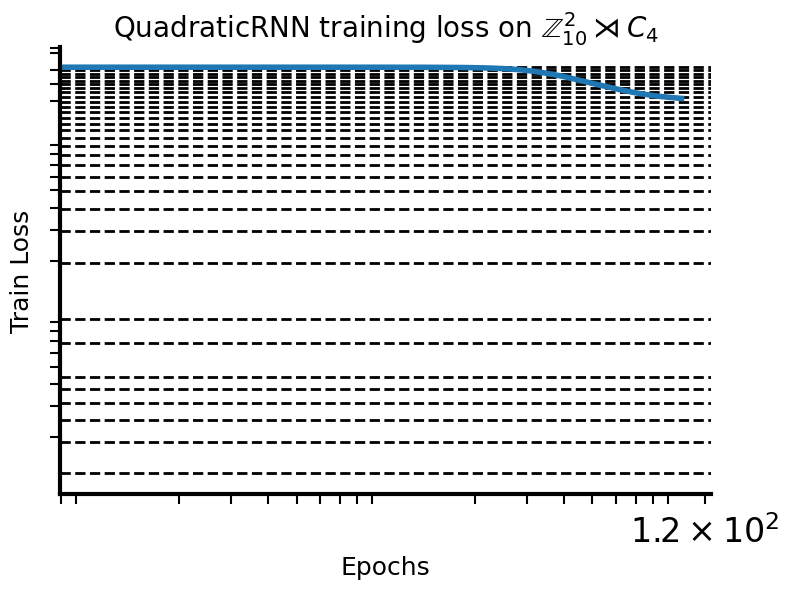

In [87]:
theory_levels = viz.loss_plateau_predictions(tpl, group)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rnn_loss_history, lw=4)

for level in theory_levels[:-1]:
    ax.axhline(y=level, color="black", linestyle="--", linewidth=2, zorder=-2)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Epochs", fontsize=18)
ax.set_ylabel("Train Loss", fontsize=18)
ax.set_title(f"QuadraticRNN training loss on {group_label_latex}", fontsize=20)
viz.style_axes(ax)
ax.grid(False)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/{file_tag}_rnn_loss.pdf", bbox_inches="tight")
plt.show()

### Comparison: TwoLayerMLP vs QuadraticRNN

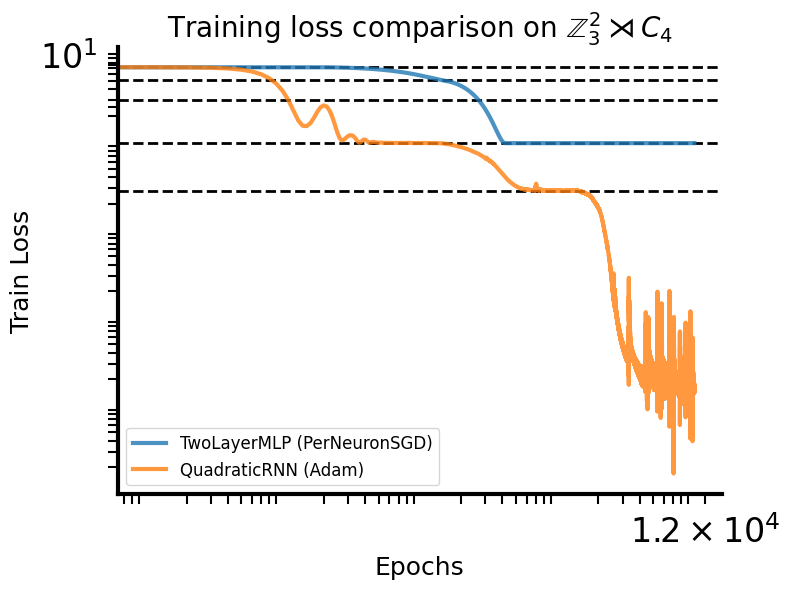

In [51]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(loss_history, lw=3, label="TwoLayerMLP (PerNeuronSGD)", alpha=0.8)
ax.plot(rnn_loss_history, lw=3, label="QuadraticRNN (Adam)", alpha=0.8)

for level in theory_levels[:-1]:
    ax.axhline(y=level, color="black", linestyle="--", linewidth=2, zorder=-2)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Epochs", fontsize=18)
ax.set_ylabel("Train Loss", fontsize=18)
ax.set_title(f"Training loss comparison on {group_label_latex}", fontsize=20)
ax.legend(fontsize=12)
viz.style_axes(ax)
ax.grid(False)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/{file_tag}_comparison.pdf", bbox_inches="tight")
plt.show()

## Power Spectrum Over Training

Computing power at step 1 with output shape (25, 36)
Computing power at step 60 with output shape (25, 36)
Computing power at step 86 with output shape (25, 36)
Computing power at step 121 with output shape (25, 36)
Computing power at step 172 with output shape (25, 36)
Computing power at step 243 with output shape (25, 36)
Computing power at step 344 with output shape (25, 36)
Computing power at step 488 with output shape (25, 36)
Computing power at step 690 with output shape (25, 36)
Computing power at step 977 with output shape (25, 36)
Computing power at step 1382 with output shape (25, 36)
Computing power at step 1956 with output shape (25, 36)
Computing power at step 2768 with output shape (25, 36)
Computing power at step 3917 with output shape (25, 36)
Computing power at step 5542 with output shape (25, 36)
Computing power at step 7842 with output shape (25, 36)


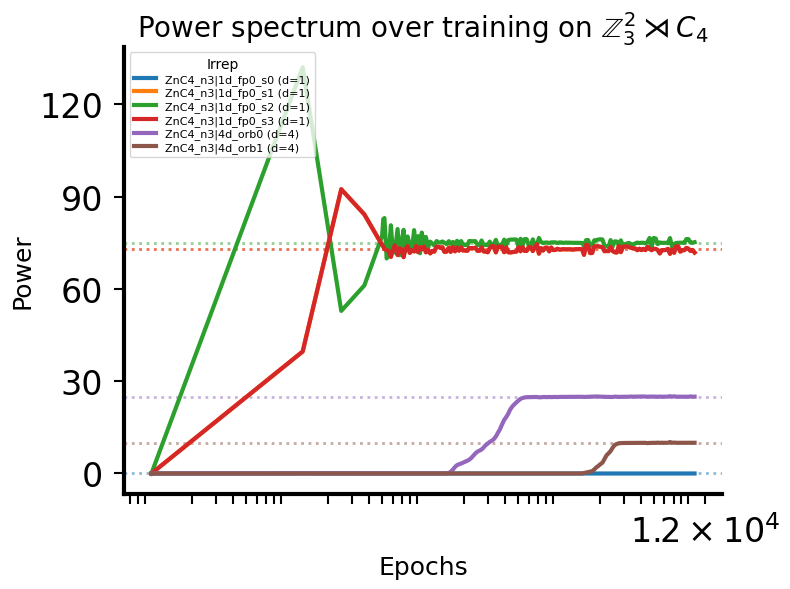

In [44]:
powers_over_time, power_steps = viz.model_power_over_time(
    group,
    model=rnn_net,
    param_history=rnn_param_history,
    model_inputs=X_tensor,
)

template_pwr = group.power_spectrum(tpl)

irreps = group.irreps()
n_irreps = len(irreps)

colors = plt.cm.tab10.colors
fig, ax = plt.subplots(figsize=(8, 6))

for k in range(n_irreps):
    color = colors[k % len(colors)]
    label = f"{irreps[k]} (d={irreps[k].dim})"
    ax.plot(power_steps, powers_over_time[:, k], color=color, lw=3, label=label)
    ax.axhline(template_pwr[k], color=color, linestyle="dotted", linewidth=2, alpha=0.5, zorder=-10)

ax.set_xscale("log")
ax.set_ylabel("Power", fontsize=18)
ax.set_xlabel("Epochs", fontsize=18)
ax.set_title(f"Power spectrum over training on {group_label_latex}", fontsize=20)
ax.legend(fontsize=8, title="Irrep", title_fontsize=10, loc="upper left", labelspacing=0.25)
viz.style_axes(ax)
ax.grid(False)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/{file_tag}_power_spectrum.pdf", bbox_inches="tight")
plt.show()

## Irreducible Representations

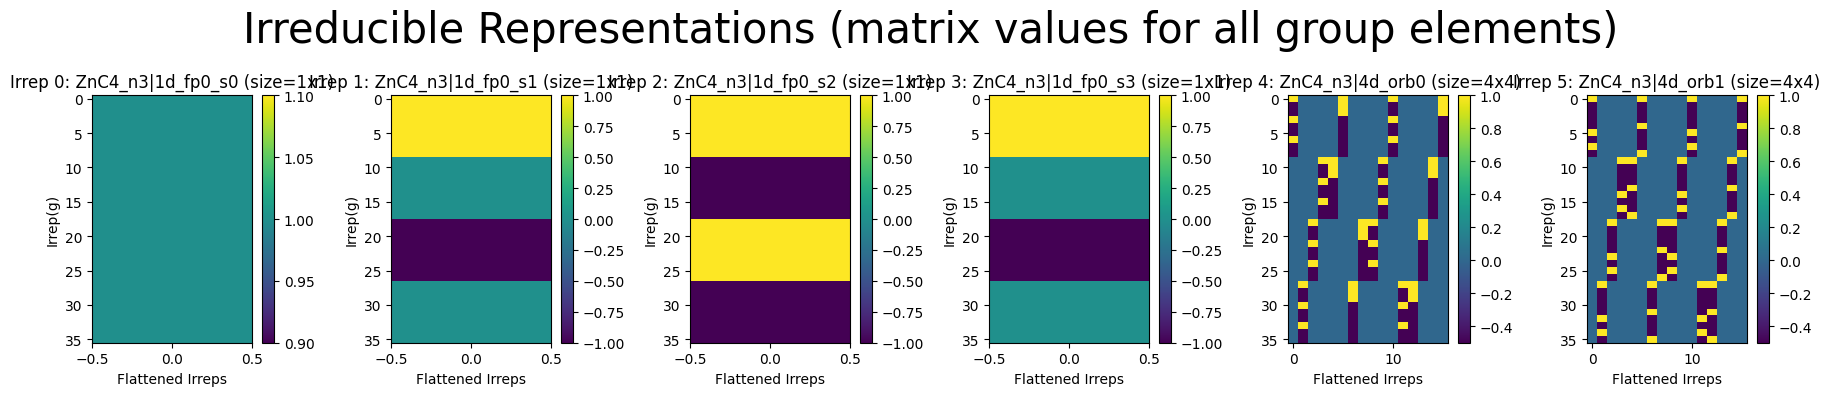

In [14]:
fig = viz.plot_irreps(group, show=False)
plt.savefig(f"{FIGURES_DIR}/{file_tag}_irreps.pdf", bbox_inches="tight")
plt.show()

## Quick Visualization of Weights

/var/folders/4g/shvz3x5d6rx38cxrtg_wmtw80000gn/T/ipykernel_34808/3596575407.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


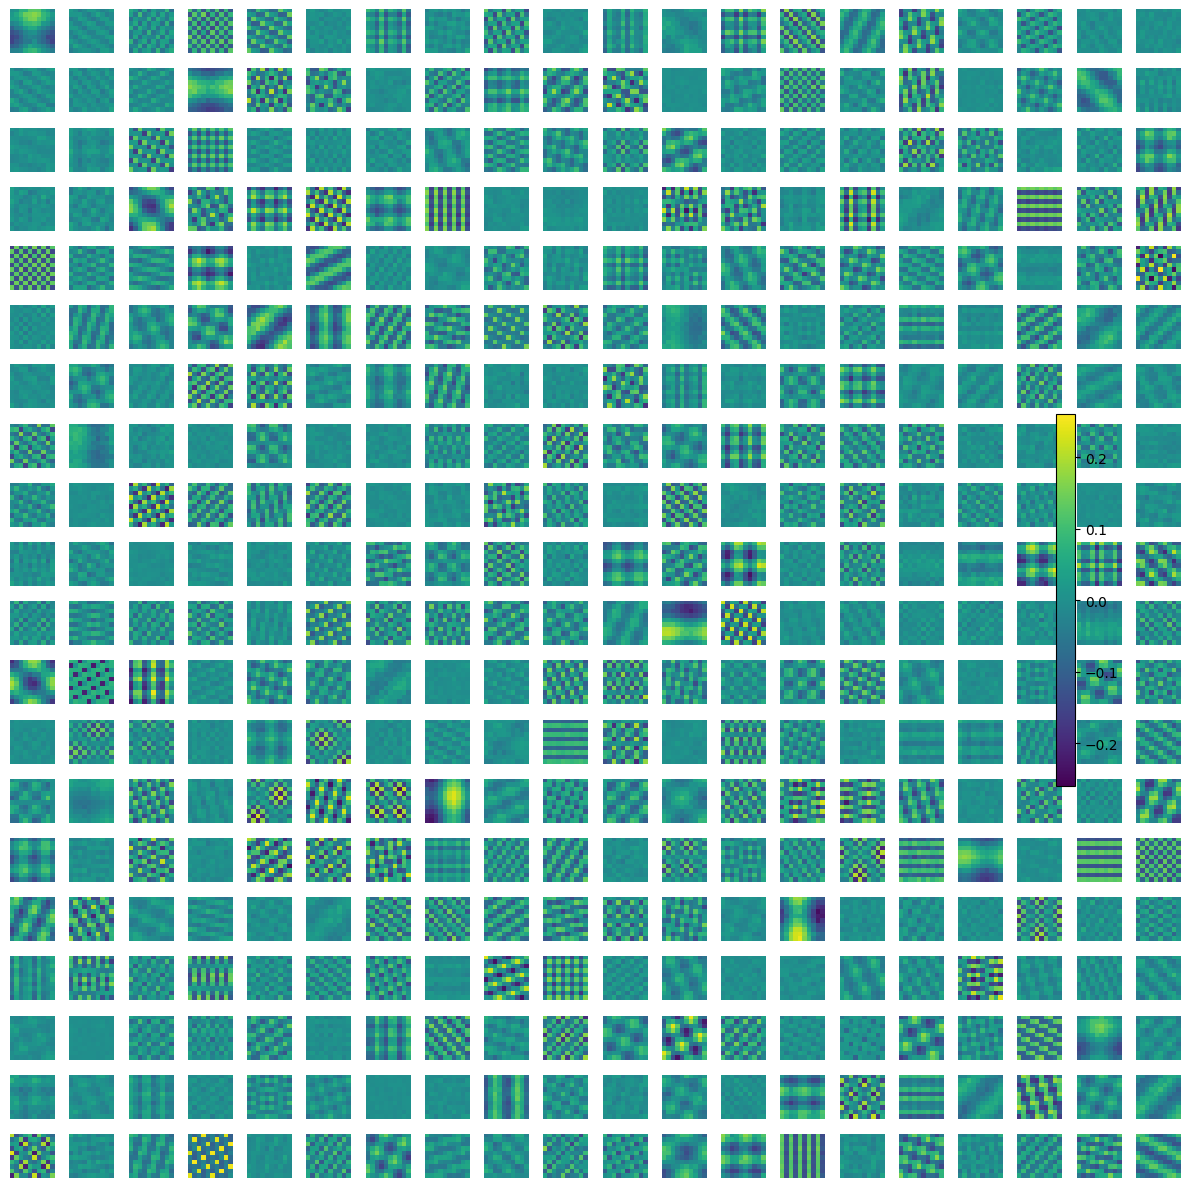

In [150]:
t = -1
param = "W_out"
rows, cols = 20, 20

W_all = rnn_param_history[t][param].detach().cpu().numpy()

# First pass: compute all images so we can set one shared color scale
images = []
for idx in range(min(rows * cols, W_all.shape[1])):
    w = W_all[:, idx]
    wsum = w.reshape(4, n, n).sum(axis=0)
    images.append(wsum)

vmin = min(img.min() for img in images)
vmax = max(img.max() for img in images)
norm = Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(rows, cols, figsize=(12, 12))
axes = np.asarray(axes).reshape(rows, cols)

im = None
for k, ax in enumerate(axes.flat):
    if k < len(images):
        im = ax.imshow(images[k], cmap="viridis", norm=norm)
    ax.axis("off")

# one shared colorbar for all subplots
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.01)

plt.tight_layout()
plt.show()

## Output Weights of RNN

In [152]:
# STEP 1: Process Ouput Weights
t = -1
param = "W_out"

# ---- load weights ----
W_all = rnn_param_history[t][param].detach().cpu().numpy()   # shape: (4*n*n, H)
num_neurons = W_all.shape[1]

# ---- build image + group label for every neuron ----
images = []
group_ids = []

for idx in range(num_neurons):
    w = W_all[:, idx]

    # image to display
    wsum = w.reshape(4, n, n).sum(axis=0)
    images.append(wsum)

    # group by argmax of power spectrum
    pwr = group.power_spectrum(w)
    gid = int(np.argmax(pwr))
    group_ids.append(gid)

group_ids = np.array(group_ids)

# ---- organize neurons by group ----
unique_groups = np.unique(group_ids)
neurons_by_group = {gid: np.where(group_ids == gid)[0].tolist() for gid in unique_groups}

# optional: sort neurons within each group by max power, descending
for gid in unique_groups:
    neurons_by_group[gid].sort(
        key=lambda idx: group.power_spectrum(W_all[:, idx])[gid],
        reverse=True
    )

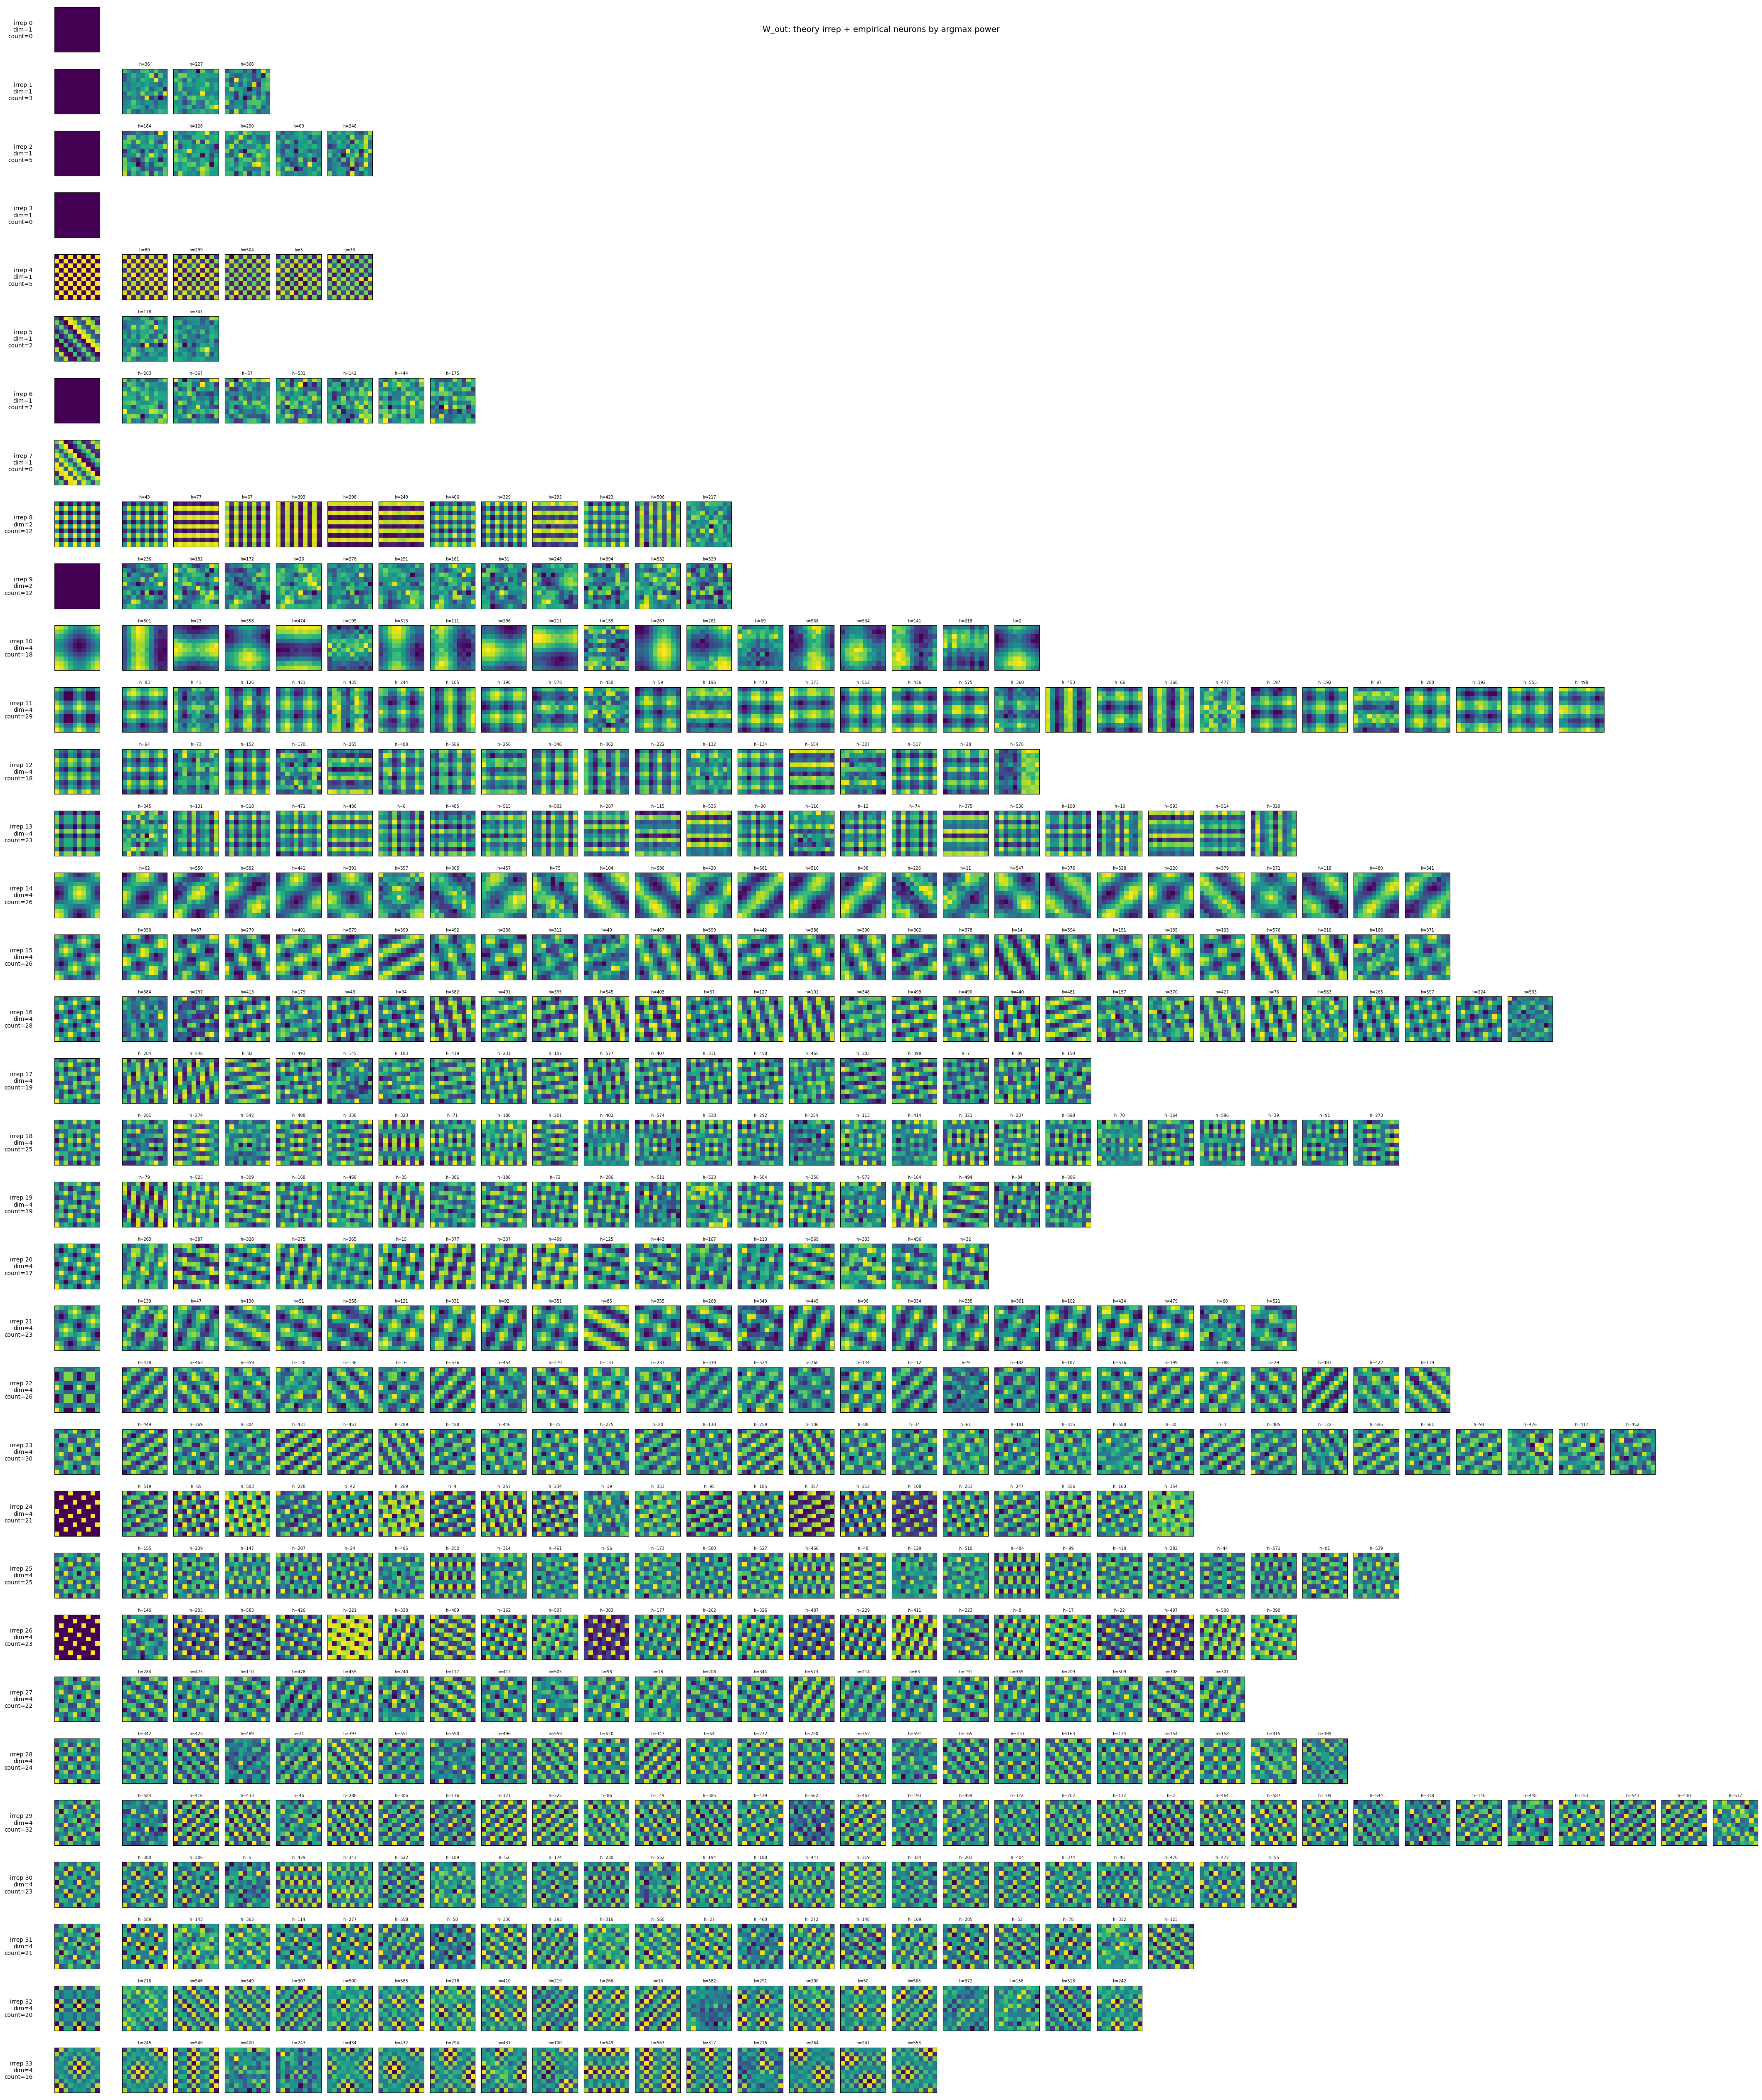

In [153]:
# -----------------------------
# theory irreps -> images
# -----------------------------
irreps = group.irreps()
group_elements = group.elements()

irrep_images = []
irrep_dims = []

for irrep in irreps:
    mats = np.array([irrep(g) for g in group_elements])

    if mats.ndim == 1:
        mats = mats[:, None, None]

    d = mats.shape[1]
    irrep_dims.append(d)

    vals = mats.real.reshape(4, n, n, d, d)
    img = vals.sum(axis=0).sum(axis=(-1, -2))   # (n, n)
    irrep_images.append(img)

# -----------------------------
# all rows = all irreps
# -----------------------------
all_groups = list(range(len(irreps)))
max_neurons = max([len(neurons_by_group.get(gid, [])) for gid in all_groups] + [1])

# columns:
#   0 = theory
#   1 = blank spacer
#   2.. = empirical neurons
nrows = len(all_groups)
ncols = 2 + max_neurons

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(1.25 * ncols, 1.5 * nrows),
    squeeze=False,
    gridspec_kw={"width_ratios": [1.0, 0.22] + [1.0] * max_neurons}
)

cmap = "viridis"

for r, gid in enumerate(all_groups):
    neuron_list = neurons_by_group.get(gid, [])
    group_size = len(neuron_list)

    # theory panel
    ax_theory = axes[r, 0]
    ax_theory.imshow(irrep_images[gid], cmap=cmap, origin="lower")
    ax_theory.set_xticks([])
    ax_theory.set_yticks([])

    # spacer column
    axes[r, 1].axis("off")

    # empirical panels
    for c in range(max_neurons):
        ax = axes[r, c + 2]
        if c < group_size:
            idx = neuron_list[c]
            ax.imshow(images[idx], cmap=cmap, origin="lower")
            ax.set_title(f"h={idx}", fontsize=7)
            ax.set_xticks([])
            ax.set_yticks([])
        else:
            ax.axis("off")

    # row label
    ax_theory.set_ylabel(
        f"irrep {gid}\ndim={irrep_dims[gid]}\ncount={group_size}",
        rotation=0,
        ha="right",
        va="center",
        labelpad=38,
        fontsize=10
    )

fig.suptitle(f"{param}: theory irrep + empirical neurons by argmax power", fontsize=14)
plt.tight_layout()
plt.show()